## ML Classical Baselines

In [1]:
import importlib
from pathlib import Path

from IPython.display import display

import utils.ml_pipeline as ml_pipeline
import utils.plots as ml_plots

importlib.reload(ml_pipeline)
importlib.reload(ml_plots)

from utils.cache import get_cache_path, get_results_path
from utils.ml_pipeline import (
    best_confusion_predictions,
    load_all_predictions,
    load_feature_dataframes,
    load_lovo_summary_tables,
    load_or_build_none_reference_features,
    load_params_lookup,
    load_raw_csi_data,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
    plot_block_vs_lovo_position_accuracy,
    plot_lovo_fold_spread,
    print_normalization_discriminability,
    run_global_baselines,
    run_optional_grid_search,
    save_analysis_tables,
    save_lovo_analysis_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)

#### Project Configurations

In [8]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "data"
CALIBRATION_MODE = "rssi"   # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_user"  # per_user | global (empty_baseline only)

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 60,
    "overlap_size": 30,
    "require_all_esps": False,
}

# MODELS_TO_RUN = ("RF", "KNN", "SVM")
MODELS_TO_RUN = ("RF", )
BANDS_TO_RUN = ("2.4 GHz", "5 GHz", "Fusion")
SPLIT_MODES = ("block", "lovo")      # "random" remains available for contamination demonstrations.
RUN_GRID_SEARCH = False
FORCE_RETRAIN = False
SAVE_PREDICTIONS = True
SVM_KERNEL = "rbf"            # "rbf" | "linear"
N_JOBS = -1

BLOCK_COUNT = 10
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0
SVM_FUSION_FALLBACK_SECONDS = 30 * 60

CONFUSION_DATASET = "Fusion"
CONFUSION_MODEL = "best"      # "best", "RF", "KNN", or "SVM"

SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
if preproc_opts.get("normalization") == "empty_baseline":
    preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)
feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path(preproc_opts, feat_opts)
print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
summary_dir = results_dir / "summary"
tables_dir = results_dir / "tables"
tuning_dir = results_dir / "tuning"
plots_dir = results_dir / "plots"
for directory in (summary_dir, tables_dir, tuning_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")

Feature cache path: c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30
Results path: c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30


## Raw Data

In [3]:
magnitude_data, csv_diagnostics = load_raw_csi_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
)

Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19


#### Feature Dataframes

In [4]:
feature_dataframes = load_feature_dataframes(
    magnitude_data,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    bands_to_run=BANDS_TO_RUN,
)

none_reference_dataframes = (
    feature_dataframes
    if preproc_opts.get("normalization") == "none"
    else load_or_build_none_reference_features(
        magnitude_data,
        active_preproc_opts=preproc_opts,
        feat_opts=feat_opts,
    )
)
fisher_diagnostics = print_normalization_discriminability(
    feature_dataframes,
    normalization=preproc_opts.get("normalization", "none"),
    reference_feature_dataframes=none_reference_dataframes,
    bands_to_run=BANDS_TO_RUN,
)
display(fisher_diagnostics)
del magnitude_data


[cache miss] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30, computing...
[Z-0 inventory]
  total Z-0 files found: 114
  breakdown by user / esp / trial:
    user=01 esp=01 trial=01: 1
    user=01 esp=02 trial=01: 1
    user=01 esp=03 trial=01: 1
    user=01 esp=04 trial=01: 1
    user=01 esp=05 trial=01: 1
    user=01 esp=07 trial=01: 1
    user=01 esp=08 trial=01: 1
    user=01 esp=09 trial=01: 1
    user=01 esp=10 trial=01: 1
    user=01 esp=11 trial=01: 1
    user=01 esp=12 trial=01: 1
    user=01 esp=13 trial=01: 1
    user=01 esp=14 trial=01: 1
    user=01 esp=15 trial=01: 1
    user=01 esp=16 trial=01: 1
    user=01 esp=17 trial=01: 1
    user=01 esp=18 trial=01: 1
    user=01 esp=19 trial=01: 1
    user=01 esp=20 trial=01: 1
    user=02 esp=01 trial=01: 1
    user=02 esp=02 trial=01: 1
    user=02 esp=03 trial=01: 1
    user=02 esp=04 trial=01: 1
    user=0

,dataset,normalization,median_fisher_ratio,none_median_fisher_ratio
0,2.4 GHz,empty_baseline,0.095734,0.050891
1,5 GHz,empty_baseline,0.080451,0.028059
2,Fusion,empty_baseline,0.088057,0.035583


#### Model Parameters

In [10]:
TUNED_SUMMARY_PATH = tuning_dir / "tuned_summary.csv"
GRID_LOG_PATH = tuning_dir / "full_grid_log.csv"

params_lookup = load_params_lookup(
    TUNED_SUMMARY_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
)
for key, value in params_lookup.items():
    print(f"{key}: {value}")

('RF', '2.4 GHz'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', '5 GHz'): {'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', 'Fusion'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}


##### Optional Grid Search

In [11]:
grid_ran = run_optional_grid_search(
    feature_dataframes,
    run_grid_search=RUN_GRID_SEARCH,
    tuned_summary_path=TUNED_SUMMARY_PATH,
    grid_log_path=GRID_LOG_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
if grid_ran:
    raise SystemExit("RUN_GRID_SEARCH=True completed; set it to False before running experiments.")

#### Global 52-Class Baselines

In [12]:
global_summary, global_predictions_by_key = run_global_baselines(
    feature_dataframes,
    params_lookup=params_lookup,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    results_dir=results_dir,
    summary_dir=summary_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    force_retrain=FORCE_RETRAIN,
    save_predictions=SAVE_PREDICTIONS,
    svm_fallback_seconds=SVM_FUSION_FALLBACK_SECONDS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
display(global_summary)

[predictions] Saved c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30\predictions\2_4ghz__rf__block.parquet
[baseline] 2.4 GHz / RF / block: majority_position_accuracy=0.0223, majority_room_accuracy=0.6541
[LOVO check] 2.4 GHz: every observed position has at least two users.
[LOVO check] 2.4 GHz: held_out_user=01 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=02 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=03 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=04 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=05 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_use

,dataset,model,split,n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,position_accuracy,macro_f1,...,majority_position_accuracy_std,majority_position_accuracy_min,majority_position_accuracy_max,majority_room_accuracy_mean,majority_room_accuracy_std,majority_room_accuracy_min,majority_room_accuracy_max,n_folds,n_test_windows,position_accuracy_pooled
0,2.4 GHz,RF,block,500,log2,None,2,1,0.863129,0.863928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.4 GHz,RF,lovo,500,log2,None,2,1,NaN,NaN,...,0.001329,0.018701,0.022508,0.653166,0.013275,0.630940,0.672266,6.0,17710.0,0.173857
2,5 GHz,RF,block,500,sqrt,None,2,1,0.873976,0.874164,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5 GHz,RF,lovo,500,sqrt,None,2,1,NaN,NaN,...,0.000397,0.019114,0.020151,0.656967,0.006107,0.651763,0.668993,6.0,19302.0,0.123770
4,Fusion,RF,block,500,log2,None,2,1,0.930897,0.931548,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Fusion,RF,lovo,500,log2,None,2,1,NaN,NaN,...,0.001333,0.018701,0.022548,0.653864,0.013400,0.631353,0.672266,6.0,17670.0,0.183248


#### Analysis Tables

In [17]:
all_global_predictions = load_all_predictions(
    results_dir,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
)

master_table = master_results_table(
    all_global_predictions,
    summary_path=summary_dir / "global_summary.csv",
)
per_room_table = per_room_position_accuracy_table(all_global_predictions)
save_analysis_tables(master_table, per_room_table, tables_dir=tables_dir)

display(master_table)
display(per_room_table)

[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30\predictions\2_4ghz__rf__block.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30\predictions\2_4ghz__rf__lovo.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30\predictions\5ghz__rf__block.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-empty_baseline_scope-per_user\feat=win60-step30\predictions\5ghz__rf__lovo.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\res

,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,...,rmse_distance_error_std,p90_distance_error_mean,p90_distance_error_std,position_accuracy_pooled,majority_position_accuracy,majority_room_accuracy,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,RF,2.4 GHz,block,0.863129,0.863928,0.979916,0.37234,0.0,1.368956,1.0,...,NaN,NaN,NaN,NaN,0.022316,0.654104,147.722858,0.856637,148.901271,RandomForestClassifier
1,RF,2.4 GHz,lovo,0.1727 +/- 0.0642,0.1392 +/- 0.0634,0.5961 +/- 0.0770,3.9687 +/- 0.2615,3.0277 +/- 0.7744,5.2721 +/- 0.2216,9.4614 +/- 0.9886,...,0.221646,9.461439,0.988636,0.173857,0.020057,0.653166,992.707709,4.657419,1013.150120,RandomForestClassifier
2,RF,5 GHz,block,0.873976,0.874164,0.994906,0.243624,0.0,0.846987,1.0,...,NaN,NaN,NaN,NaN,0.022591,0.658472,517.400841,1.257519,519.275115,RandomForestClassifier
3,RF,5 GHz,lovo,0.1237 +/- 0.0549,0.0916 +/- 0.0404,0.6773 +/- 0.1385,3.6815 +/- 0.4810,3.4360 +/- 0.4823,4.4529 +/- 0.5183,7.3692 +/- 1.1112,...,0.518320,7.369151,1.111189,0.123770,0.019482,0.656967,4031.427533,7.453172,4055.110311,RandomForestClassifier
4,RF,Fusion,block,0.930897,0.931548,0.994531,0.154789,0.0,0.822109,0.0,...,NaN,NaN,NaN,NaN,0.022371,0.655481,139.724957,1.829435,142.177192,RandomForestClassifier
5,RF,Fusion,lovo,0.1836 +/- 0.0875,0.1495 +/- 0.0742,0.6853 +/- 0.1577,3.4129 +/- 0.7067,2.9164 +/- 1.1804,4.3594 +/- 0.6515,7.0710 +/- 1.1047,...,0.651454,7.071037,1.104738,0.183248,0.019943,0.653864,1035.018975,5.691996,1056.606862,RandomForestClassifier


,model,dataset,split,true_room,samples,position_accuracy
0,RF,2.4 GHz,block,1,2638,0.853298
1,RF,2.4 GHz,block,2,768,0.865885
2,RF,2.4 GHz,block,3,627,0.901116
3,RF,2.4 GHz,lovo,1,11564,0.155223
4,RF,2.4 GHz,lovo,2,3373,0.217907
5,RF,2.4 GHz,lovo,3,2773,0.197981
6,RF,5 GHz,block,1,2973,0.861083
7,RF,5 GHz,block,2,862,0.900232
8,RF,5 GHz,block,3,680,0.897059
9,RF,5 GHz,lovo,1,12682,0.108264


#### LOVO cross-user analysis


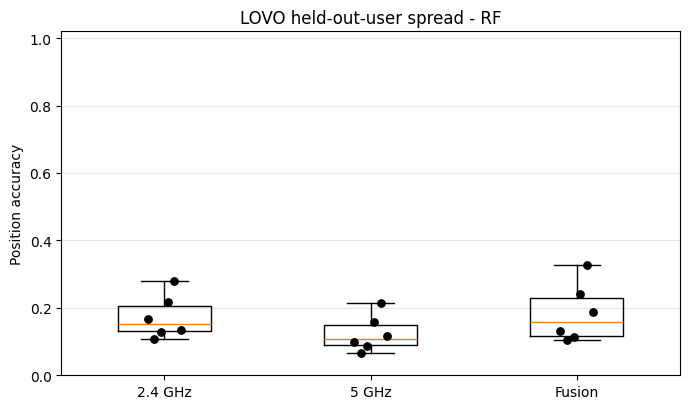

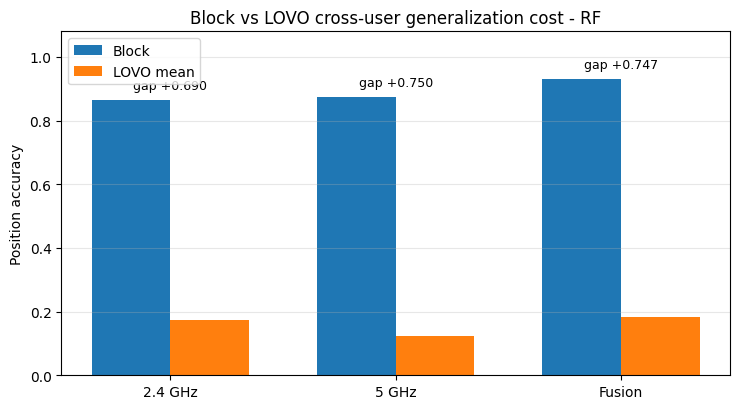

,model,dataset,position_accuracy_mean_std,macro_f1_mean_std,room_accuracy_mean_std,mean_distance_error_mean_std,median_distance_error_mean_std,rmse_distance_error_mean_std,p90_distance_error_mean_std,majority_position_accuracy_mean_std,majority_room_accuracy_mean_std
0,RF,2.4 GHz,0.1727 +/- 0.0642,0.1392 +/- 0.0634,0.5961 +/- 0.0770,3.9687 +/- 0.2615,3.0277 +/- 0.7744,5.2721 +/- 0.2216,9.4614 +/- 0.9886,0.0201 +/- 0.0013,0.6532 +/- 0.0133
1,RF,5 GHz,0.1237 +/- 0.0549,0.0916 +/- 0.0404,0.6773 +/- 0.1385,3.6815 +/- 0.4810,3.4360 +/- 0.4823,4.4529 +/- 0.5183,7.3692 +/- 1.1112,0.0195 +/- 0.0004,0.6570 +/- 0.0061
2,RF,Fusion,0.1836 +/- 0.0875,0.1495 +/- 0.0742,0.6853 +/- 0.1577,3.4129 +/- 0.7067,2.9164 +/- 1.1804,4.3594 +/- 0.6515,7.0710 +/- 1.1047,0.0199 +/- 0.0013,0.6539 +/- 0.0134


,model,dataset,held_out_user,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,samples,majority_position_accuracy,majority_room_accuracy,n_test_windows,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,RF,2.4 GHz,1,0.166877,0.131409,0.540617,4.083484,3.605551,5.359318,9.219544,3176.0,0.020466,0.655227,3176,125.268094,0.659023,126.120807,RandomForestClassifier
1,RF,2.4 GHz,2,0.108967,0.083505,0.540907,4.285035,4.000000,5.315653,9.000000,2799.0,0.022508,0.630940,2799,192.060507,0.796985,193.174309,RandomForestClassifier
2,RF,2.4 GHz,3,0.129382,0.092930,0.508604,4.220124,3.162278,5.405218,9.486833,3138.0,0.019758,0.650733,3138,182.543957,0.834517,183.659704,RandomForestClassifier
3,RF,2.4 GHz,4,0.217054,0.165557,0.705103,3.771406,2.000000,5.464414,11.000000,3096.0,0.019380,0.656654,3096,182.954381,0.808917,183.980162,RandomForestClassifier
4,RF,2.4 GHz,5,0.278817,0.253922,0.642979,3.660047,2.236068,5.240720,10.000000,2941.0,0.018701,0.653179,2941,177.313907,0.797513,178.385079,RandomForestClassifier
5,RF,2.4 GHz,6,0.135156,0.108055,0.638672,3.791903,3.162278,4.847317,8.062258,2560.0,0.019531,0.672266,2560,132.566864,0.760463,133.548391,RandomForestClassifier
6,RF,5 GHz,1,0.098301,0.073832,0.712682,3.798527,3.605551,4.423740,7.071068,3296.0,0.019114,0.668993,3296,919.707016,0.700413,920.640016,RandomForestClassifier
7,RF,5 GHz,2,0.065491,0.049860,0.634761,4.325997,4.242641,4.871491,7.071068,3176.0,0.020151,0.651763,3176,771.880787,0.493023,772.504340,RandomForestClassifier
8,RF,5 GHz,3,0.087324,0.061126,0.437246,4.056258,3.605551,4.824689,8.062258,3195.0,0.019405,0.655399,3195,437.019867,0.703747,437.939575,RandomForestClassifier
9,RF,5 GHz,4,0.159161,0.120856,0.830352,3.278428,3.162278,4.013049,6.708204,3242.0,0.019741,0.655768,3242,470.297586,0.577544,471.020303,RandomForestClassifier


In [14]:
if "lovo" in SPLIT_MODES:
    lovo_per_fold, lovo_summary = load_lovo_summary_tables(summary_dir)
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)
    save_lovo_analysis_table(lovo_table, tables_dir=tables_dir)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('lovo rf fold spread')}.pdf",
    )
    plot_block_vs_lovo_position_accuracy(
        globals().get("global_summary", master_table),
        lovo_summary,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('block vs lovo rf position accuracy')}.pdf",
    )

    display(lovo_table)
    display(lovo_per_fold.loc[lovo_per_fold["model"] == "RF"])
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")

#### Analysis Figures

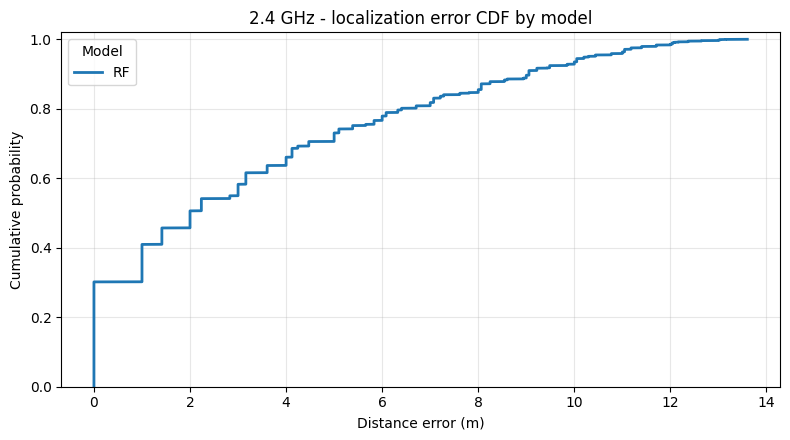

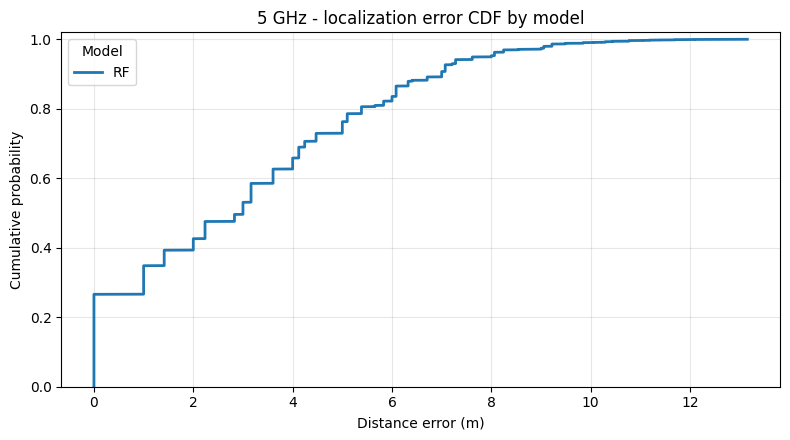

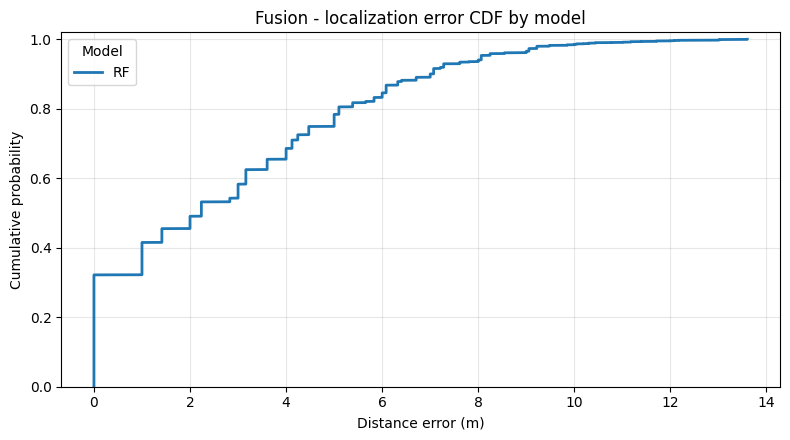

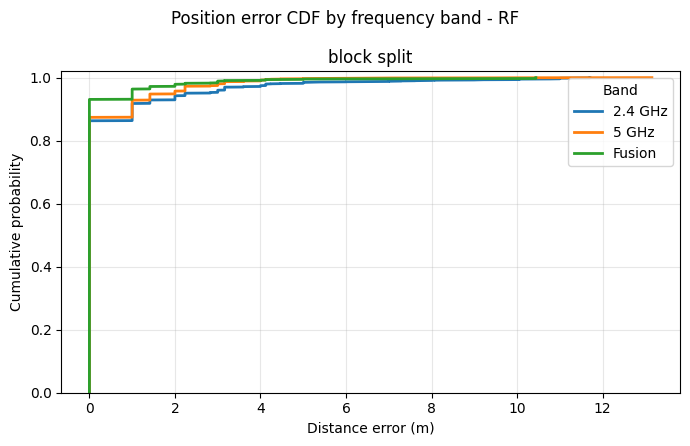

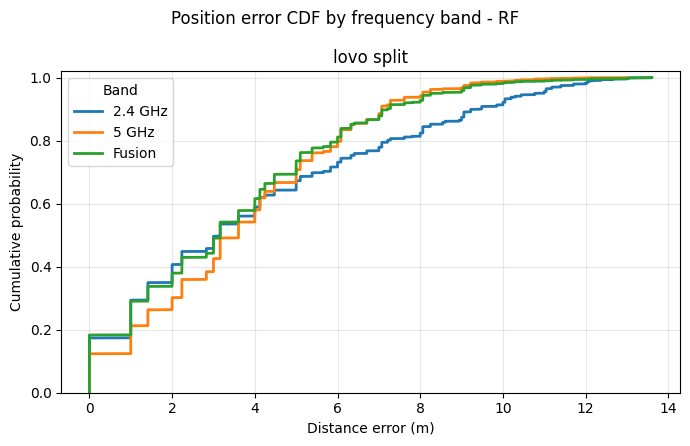

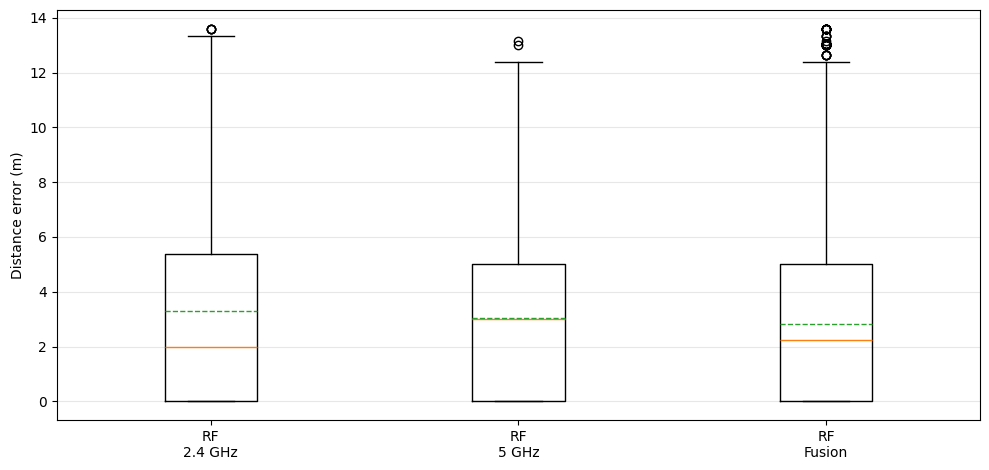

In [15]:
if SHOW_CDF_BY_BAND:
    for band in BANDS_TO_RUN:
        plot_localization_error_cdf_by_model(
            all_global_predictions,
            dataset=band,
            save_path=plots_dir / f"cdf_by_model_{_slugify(band)}.pdf",
        )

if SHOW_CDF_BY_MODEL:
    for model in MODELS_TO_RUN:
        model_predictions = all_global_predictions.loc[all_global_predictions["model"] == model]
        plot_band_error_cdf(
            model_predictions,
            model_label=model,
            split_modes=SPLIT_MODES,
            band_order=BANDS_TO_RUN,
            save_path=plots_dir,
        )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_global_predictions,
        models=MODELS_TO_RUN,
        bands=BANDS_TO_RUN,
        save_path=plots_dir / "boxplot_model_band_distance_error.pdf",
    )

#### Confusion Matrix And Floor Plan

In [16]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_global_predictions,
    master_table,
    dataset=CONFUSION_DATASET,
    model=CONFUSION_MODEL,
)
print(f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET}")

if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=f"{CONFUSION_DATASET} / {confusion_model} localization heatmap",
        save_path=plots_dir / f"floor_plan_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.pdf",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=plots_dir / f"confusion_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.pdf",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = plots_dir / f"confusion_by_room_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )

TypeError: '<' not supported between instances of 'float' and 'str'